# Imports

In [1]:
import tensorflow
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Carregando o dataset

In [2]:
dataset = keras.datasets.fashion_mnist
((imagens_treino, identificacoes_treino),(imagens_teste, identificacoes_teste))= dataset.load_data()

# Exploração os Dados

In [3]:
imagens_treino

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [4]:
len(imagens_treino) # Verificando qual a extensão deste imagens_treino / resultado de 60000 imagens

60000

In [5]:
imagens_treino.shape # Tem um array de 28 linhas e 28 colunas / dimensão das imagens 28 x 28

(60000, 28, 28)

In [6]:
len(imagens_teste) # Verificando qual a extensão deste imagens_teste / resultado de 10000 imagens

10000

In [7]:
imagens_teste.shape # Tem um array de 28 linhas e 28 colunas / dimensão das imagens 28 x 28

(10000, 28, 28)

In [8]:
len(identificacoes_treino) # Identificações / Labels

60000

In [9]:
identificacoes_treino.shape

(60000,)

In [10]:
len(identificacoes_teste) # Identificações / Labels

10000

In [11]:
identificacoes_teste.shape

(10000,)

In [12]:
identificacoes_treino.min()  # Valor mínimo das identificações é 0
identificacoes_treino.max()  # Valor máximo das identificações é 9

np.uint8(9)

# Exibição os dados 

In [13]:
# Com isto sabemos que temos 10 posições de 0 a 9, ou seja, 10 classificações de imagens
total_de_classificacoes = 10  
nomes_de_classificacoes = ['Camiseta', 'Calça', 'Pullover', 
                        'Vestido', 'Casaco', 'Sandália', 
                        'Camisa', 'Tênis', 'Bolsa', 'Bota']

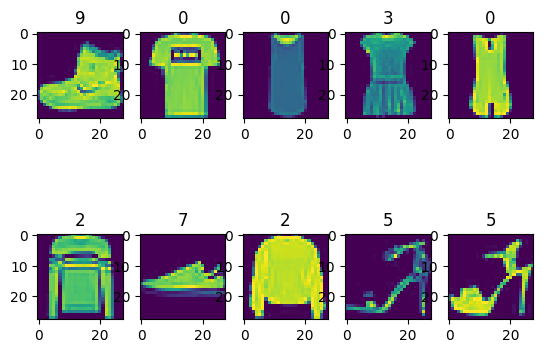

In [14]:
# plt.imshow(imagens_treino[0])
# plt.title(identificacoes_treino[0]) # Título retorna o valor 9
for imagem in range (10):
    plt.subplot(2, 5, imagem+1)
    plt.imshow(imagens_treino[imagem])
    plt.title(identificacoes_treino[imagem]) 

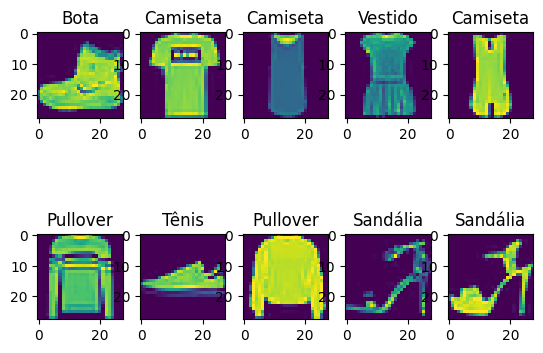

In [15]:
# Retornando com os nomes das classificações no título de cada Imagem
for imagem in range (10):
    plt.subplot(2, 5, imagem+1)
    plt.imshow(imagens_treino[imagem])
    plt.title(nomes_de_classificacoes[identificacoes_treino[imagem]]) 

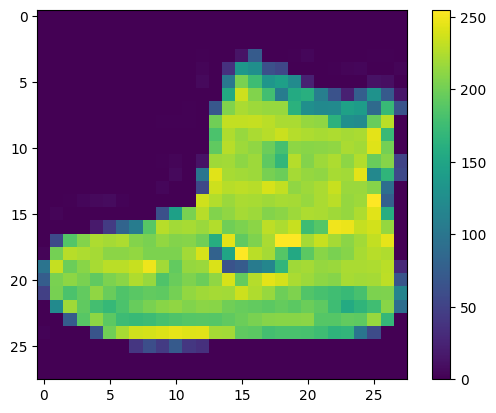

In [16]:
plt.imshow(imagens_treino[0])
plt.colorbar()

# Criando o Modelo e suas Camadas

Função ReLU (Aprendizagem não linear):  todos os números negativos se tornam 0, é por isto que esta função transforma. todos os números positivos se mantêm, ou seja, continuarão sendo positivos.

Além disso, ela faz outra coisa muito importante em Redes Neurais, redes como Deep Learning, redes mais profundas, em casos de não se formar uma linha no gráfico na ligação de 2 pontos entre eixo x e eixo y, ou seja, trata-se de uma função não linear, então a ReLU introduz na nossa Rede Neural Profunda funções não lineares. 

Mas vejamos como exemplo as imagens das roupas desse projeto, temos a camisa perto da camiseta, da calça, da saia, do sapato. Elas estão juntas, mas você consegue enxergar uma linha acontecendo? Não tem como, então teremos que traçar essas separações agrupamentos por meio de curvas, resultando em mais ou menos 5 áreas.

Essa é uma função não linear, e é por isso que usamos a ReLU, porque não conseguiremos separar as nossas imagens com apenas uma linha, e foi por isso, também, que essas funções surgiram dentro de Machine Learning, de Redes Neurais, para conseguirmos classificar coisas como este conjunto de dados que não separaremos com uma linha.

In [17]:
# Fazendo o processo de normalização de dividir as imagens de treino por 255
# através dessa função, onde diminuido o tamanho da quantidade que o modelo deve processar faz com que diminui o loss do modelo
imagens_treino = imagens_treino/float(255) 

In [18]:
# Camadas
modelo = keras.Sequential([
    # Entrada Camada 0 / Nesta primeira camada está pegando um array de duas dimensões de 28x28 e achatando a imagem para uma dimensão só
    keras.layers.Flatten(input_shape=(28, 28)),  
    
    # Processamento Camada 1 / Camada com 256 Funções(bolinhas redes neurais) densas fazendo com que esta funções desta camada 1 se comuniquem com a camada 0 de Entrada
    keras.layers.Dense(256, activation=tensorflow.nn.relu), 
    
    # Fazendo o processo de normalização - Dropout é uma camada usada em redes neurais para prevenir overfitting, 
    # ela funciona "desligando" aleatoriamente neste caso 20% (0.2) dos neurônios durante o treinamento, 
    # ajudando o modelo a não depender demais de neurônios específicos e a generalizar melhor.
    keras.layers.Dropout(0.2), 
    
    # Saida Camada 2 / Quantidade de Categorias(Classificações) de roupas são 10  Softmax - Probabilidade destas imagens pertecerem a cada a categoria
    keras.layers.Dense(10, activation=tensorflow.nn.softmax) 
])

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compliando o Modelo

In [19]:
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
               metrics=['accuracy'])

# Treinando o Modelo

fazer testes alterando o número de épocas(epochs) para verificar o resultado da acurácia e do loss

In [20]:
historico = modelo.fit(imagens_treino, identificacoes_treino, epochs=5, validation_split= 0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8103 - loss: 0.5290 - val_accuracy: 0.8393 - val_loss: 0.4331
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8543 - loss: 0.4007 - val_accuracy: 0.8649 - val_loss: 0.3754
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8664 - loss: 0.3651 - val_accuracy: 0.8621 - val_loss: 0.3705
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8764 - loss: 0.3384 - val_accuracy: 0.8775 - val_loss: 0.3477
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8796 - loss: 0.3241 - val_accuracy: 0.8727 - val_loss: 0.3524


In [21]:
### verificar
#Salvando e fazendo o Load do Modelo
#from tensorflow.keras.models import load_model
# modelo_salvo = load_model('modelo.keras')
# modelo.save ('modelo.keras')

In [33]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [23]:
historico.history

{'accuracy': [0.8102708458900452,
  0.8542916774749756,
  0.8663541674613953,
  0.8763541579246521,
  0.8795833587646484],
 'loss': [0.5290189385414124,
  0.4006617069244385,
  0.3650888204574585,
  0.3383927643299103,
  0.3241058886051178],
 'val_accuracy': [0.8392500281333923,
  0.8649166822433472,
  0.8620833158493042,
  0.8774999976158142,
  0.8726666569709778],
 'val_loss': [0.4331108033657074,
  0.3753894865512848,
  0.3704836368560791,
  0.34770169854164124,
  0.3523745834827423]}

In [24]:
historico.history['accuracy']

[0.8102708458900452,
 0.8542916774749756,
 0.8663541674613953,
 0.8763541579246521,
 0.8795833587646484]

In [25]:
historico.history['loss']

[0.5290189385414124,
 0.4006617069244385,
 0.3650888204574585,
 0.3383927643299103,
 0.3241058886051178]

In [26]:
historico.history['val_accuracy']

[0.8392500281333923,
 0.8649166822433472,
 0.8620833158493042,
 0.8774999976158142,
 0.8726666569709778]

In [27]:
historico.history['val_loss']

[0.4331108033657074,
 0.3753894865512848,
 0.3704836368560791,
 0.34770169854164124,
 0.3523745834827423]

# Testando o Modelo a Dados Novos

In [28]:
# Neste primeiro teste da posição zero o Modelo acertou pois o resultado foi 9 e o número da imagem é 9
testes = modelo.predict(imagens_teste)
print('resultado teste:', np.argmax(testes[0]))
print('Número da imagem de teste:', identificacoes_teste[0])

# Executando teste do modelo que foi salvo
# testes_modelo_salvo = modelo_salvo.predict(imagens_teste)
# print('resultado teste modelo salvo:', np.argmax(testes_modelo_salvo[1]))
# print('Número da imagem de teste:', identificacoes_teste[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
resultado teste: 9
Número da imagem de teste: 9


# Avaliando quantas vezes o Modelo acertou e errou

 modelo.evaluate - Essa função avalia como o nosso modelo está indo com os dados de teste, fornecendo os dados de acurácia e perda

In [29]:
perda_teste, acuracia_teste = modelo.evaluate(imagens_teste, identificacoes_teste)
print('Perda do teste', perda_teste)
print('Acurácia do teste', acuracia_teste)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8456 - loss: 57.9079
Perda do teste 57.90791320800781
Acurácia do teste 0.8456000089645386


# Gráfico da Acurácia

Épocas (epochs) são as quantidades de teste predefinidos e quantas vezes o modelo executou

No gráfico de acurácia, o overfitting é identificado quando a acurácia no treino continua aumentando, mas a acurácia na validação começa a cair após certo ponto.

O que isso indica?


A acurácia de treino está subindo:
* O modelo está aprendendo muito bem os dados de treino, chegando a memorizar padrões específicos.


A acurácia de validação começa a cair:
* Isso mostra que o modelo não está conseguindo generalizar o que aprendeu para dados novos (validação).


Conclusão:
O modelo está ficando especializado demais nos dados de treino, mas desempenha mal em dados que nunca viu.
Esse desequilíbrio indica overfitting — o modelo aprendeu os dados de treino bem demais, mas isso prejudica o desempenho fora deles.

No gráfico de acurácia, o underfitting ocorre quando tanto a acurácia de treino quanto a de validação permanecem baixas e não melhoram significativamente com o tempo.

O que isso indica?

A acurácia de treino é baixa:
* O modelo não consegue aprender bem nem os dados de treino, indicando que está muito simples ou mal treinado.

A acurácia de validação também é baixa:
* O modelo não generaliza bem e nem mesmo está captando os padrões básicos do problema.

Conclusão:
O modelo está com underfitting, ou seja, não tem capacidade suficiente para representar o problema.
Ele pode precisar de:

* uma arquitetura mais complexa,
* mais épocas de treino,
* ou melhores variáveis (features).

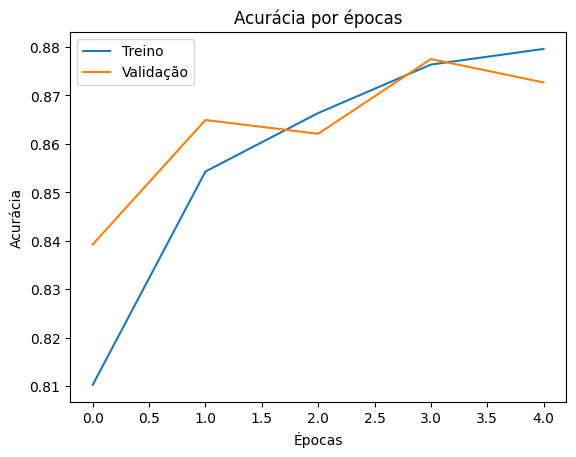

In [30]:
plt.plot(historico.history['accuracy'])
plt.plot(historico.history['val_accuracy'])
plt.title('Acurácia por épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])

# Gráfico de Perdas

No gráfico de perdas, o overfitting é identificado quando a perda (loss) no conjunto de treino continua diminuindo, mas a perda no conjunto de validação começa a aumentar após certo ponto.

A loss de treino está caindo:
O modelo está aprendendo cada vez mais os dados de treino, inclusive detalhes e ruídos.

A loss de validação começa a subir:
O modelo não consegue aplicar esse aprendizado nos dados de validação (dados novos). Ele começa a errar mais.

Conclusão:

Isso significa que o modelo está se ajustando bem demais aos dados de treino (memorizando), mas perde a capacidade de generalização.
Ou seja, ele não consegue manter um bom desempenho em dados que nunca viu — isso é o típico overfitting.

No gráfico de perdas, o underfitting ocorre quando as perdas tanto do treino quanto da validação permanecem altas e não caem muito ao longo do tempo.

O que isso indica?

A loss de treino permanece alta:
* O modelo não consegue reduzir o erro nem nos dados de treino, mostrando que não aprendeu os padrões básicos.

A loss de validação também permanece alta, próxima à perda do treino:
* O modelo não está generalizando bem, mas isso ocorre porque ele ainda não aprendeu o suficiente nem nos dados de treino.

Conclusão:

O modelo está com underfitting, indicando que é muito simples ou mal configurado para o problema.
É necessário aumentar a capacidade do modelo, ajustar parâmetros ou melhorar os dados para obter melhor aprendizado.

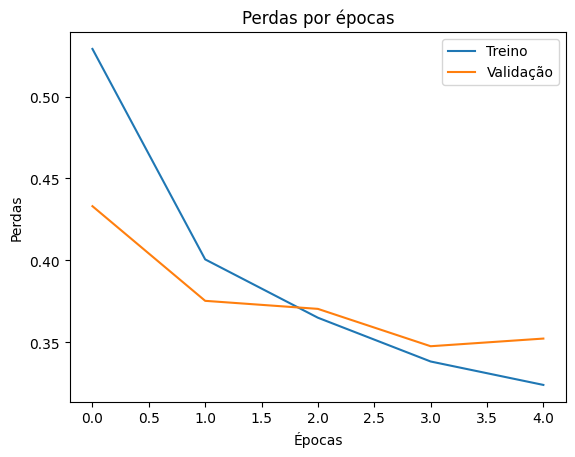

In [31]:
plt.plot(historico.history['loss'])
plt.plot(historico.history['val_loss'])
plt.title('Perdas por épocas')
plt.xlabel('Épocas')
plt.ylabel('Perdas')
plt.legend(['Treino', 'Validação'])